In [1]:
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte2d_settings_ex8_oerfm import get_config
from constraints.continuous2d_oe_2 import (
    OddEvenDecompositionPointwiseBoundaryConstraint2D as BC,
    OddEvenDecompositionPointwiseInteriorConstraint2D as EQ,
)
from geometry.meshxd_ds import UniformMeshXYV
from modules.generator_2_copy import SampleHoleCircle
from modules.solution_2_copy import (
    OddEvenDecompositionAverage2D,
    OddEvenDecompositionConstructor2D,
)
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXYV(domain=domain, strides=strides)
mesh_r = UniformMeshXYV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_y, dummy_theta = jnp.split(

    jnp.array([-0.2, -1.0, 0.2]), 3, axis=0)
params = {}
# eq_instance = rte.apply(params, dummy_x, dummy_y, dummy_theta)
# bc_instance = bc.apply(params, dummy_x, dummy_y, dummy_theta)

In [6]:
# eq_instance.shape, bc_instance.shape

In [7]:
def eq_fn(x, y, theta):
    return partial(rte.apply, params)(x, y, theta)


def bc_fn(x, y, theta):
    return partial(bc.apply, params)(x, y, theta)


def rhs_fn(x, y, theta):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures

    def q_sym1(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            + source_fn(x, y, theta + jnp.pi)
            + source_fn(x, y, -theta)
            + source_fn(x, y, -theta + jnp.pi)
        )

    def q_sym2(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            + source_fn(x, y, theta + jnp.pi)
            - source_fn(x, y, -theta)
            - source_fn(x, y, -theta + jnp.pi)
        )

    def q_asym1(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            - source_fn(x, y, theta + jnp.pi)
            + source_fn(x, y, -theta)
            - source_fn(x, y, -theta + jnp.pi)
        )

    def q_asym2(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            - source_fn(x, y, theta + jnp.pi)
            - source_fn(x, y, -theta)
            + source_fn(x, y, -theta + jnp.pi)
        )

    weighted_sum1 = vmap(q_sym1, [None, None, 0])(x, y, pts) * ws
    avg_q1 = jnp.sum(weighted_sum1) / jnp.pi * 2

    rhs = jnp.stack(
        [
            avg_q1.squeeze(),
            kn**2 * (q_sym1(x, y, theta) - avg_q1).squeeze(),
            kn * q_asym1(x, y, theta).squeeze(),
            kn**2 * q_sym2(x, y, theta).squeeze(),
            kn * q_asym2(x, y, theta).squeeze(),
        ],
        axis=0,
    )
    return rhs


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = SampleHoleCircle(
    domain=domain, collocation_sizes=collocation_sizes, mode=mode
)
pts_int, pts_left, pts_right, pts_lower, pts_upper = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
    sampler.pts_lower,
    sampler.pts_upper,
)
pts_hole = sampler.pts_hole

In [9]:
# Evaluate the functions
bc_left, bc_right, bc_lower, bc_upper = (
    vmap_bc_fn(*pts_left),
    vmap_bc_fn(*pts_right),
    vmap_bc_fn(*pts_lower),
    vmap_bc_fn(*pts_upper),
)
bc_hole = vmap_bc_fn(*pts_hole)

print(
    f"bc_left.shape: {bc_left.shape}, bc_right.shape: {bc_right.shape}, bc_lower.shape: {bc_lower.shape}, bc_upper.shape: {bc_upper.shape}"
)
print(f"bc_hole.shape: {bc_hole.shape}")

bc_left.shape: (4096, 2, 1024), bc_right.shape: (4096, 2, 1024), bc_lower.shape: (4096, 2, 1024), bc_upper.shape: (4096, 2, 1024)
bc_hole.shape: (16384, 2, 1024)


In [10]:
eq_int = vmap_eq_fn(*pts_int)
print(f"eq_int.shape: {eq_int.shape}")  # ((Nx-2) * (Ny-2) * (Ntheta-2),3,32)

eq_int.shape: (21360, 5, 1024)


In [11]:
x_int, y_int, theta_int = pts_int
pts_int = x_int.squeeze(), y_int.squeeze(), theta_int.squeeze()
rhs_int = vmap_rhs_fn(*pts_int)
print(f"rhs_int.shape: {rhs_int.shape}")

rhs_int.shape: (21360, 5)


In [12]:
def ex_solution_2d(x: jnp.ndarray, y: jnp.ndarray, theta: jnp.ndarray) -> jnp.ndarray:
    return 1 / (x**2 + y**2 + 1)


vmap_ex_fn = vmap(jit(ex_solution_2d))
kn

0.0001

In [14]:
# Save the data
matrix_A = np.concatenate(
    [
        bc_left.reshape(-1, num_unknowns * 2),
        bc_right.reshape(-1, num_unknowns * 2),
        bc_lower.reshape(-1, num_unknowns * 2),
        bc_upper.reshape(-1, num_unknowns * 2),
        bc_hole.reshape(-1, num_unknowns * 2),
        eq_int.reshape(-1, num_unknowns * 2),
    ],
    axis=0,
)

vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size_x, bdy_size_y, bdy_size_theta = collocation_sizes["boundary"]
vector_b[: 2 * bdy_size_y * bdy_size_theta: 2,
         0] = 2 * vmap_ex_fn(*pts_left).squeeze()
vector_b[
    2 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_right).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_lower).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 2 * bdy_size_x * bdy_size_theta: 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_upper).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 4 * bdy_size_x * bdy_size_theta: 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_hole).squeeze()

vector_b[
    4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta:,
    0,
] = rhs_int.reshape(-1)

print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (172336, 1024), Vector b: (172336, 1)


In [15]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

num_zero = np.sum(matrix_A == 0).item()
total = matrix_A.size
sparsity = num_zero / total
print(f"A的稀疏度 = {sparsity:.2%} (零元素比例)")
num_zero = np.sum(vector_b == 0).item()
total = vector_b.size
sparsity = num_zero / total
print(f"b的稀疏度 = {sparsity:.2%} (零元素比例)")
condition_number = np.linalg.cond(matrix_A)
print(f"A的条件数 = {condition_number:.2e}")

Matrix A 内存 1346.38 MB
Vector b 内存 1.31 MB
A的稀疏度 = 6.20% (零元素比例)
b的稀疏度 = 19.01% (零元素比例)
A的条件数 = 9.74e+08


In [16]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (1024, 1)


In [17]:
error = matrix_A @ vector_U - vector_b
(
    np.abs(error).max(),
    np.abs(error).mean(),
)

(0.08272782883518576, 0.003476906891816194)

In [19]:
n_bc = bc_left.shape[0] * 2
(
    np.abs(error)[n_bc * 0: n_bc * 1].mean(),
    np.abs(error)[n_bc * 1: n_bc * 2].mean(),
    np.abs(error)[n_bc * 2: n_bc * 3].mean(),
    np.abs(error)[n_bc * 3: n_bc * 4].mean(),
    np.abs(error)[n_bc * 4:].mean(),
)

(0.003642594964861267,
 0.003956861054786173,
 0.003665550590840487,
 0.0036567522992048775,
 0.0034173820440203504)

In [20]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [21]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns * 2,
)
constructor = OddEvenDecompositionConstructor2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)
average = OddEvenDecompositionAverage2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [22]:
def approx_fn(x, y, theta):
    return partial(constructor.apply, params)(x, y, theta)

In [23]:
def aver_fn(x, y):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures
    weighted_sum = vmap(approx_fn, [None, None, 0])(x, y, pts) @ ws
    return weighted_sum / jnp.pi * 2

In [24]:
# vmap_approx_fn = vmap(approx_fn)
approx_fn = jit(approx_fn)

In [25]:
dummy_z = jnp.array([0, 0, 0])
dummy_x, dummy_y, dummy_v = jnp.split(dummy_z, 3, axis=-1)
print(
    f"f({dummy_z}) = {approx_fn(dummy_x, dummy_y, dummy_v)}"
)  # f([0. 0. 0.]) = 1.000002714641632

f([0 0 0]) = 0.970484685848882


In [26]:
def average_fn(x, y):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures
    weighted_sum = vmap(average.apply, [None, None, None, 0])(

        params, x, y, pts) @ ws
    return weighted_sum / (jnp.pi) * 2

In [27]:
def rho(x, y):
    return 1 / (x**2 + y**2 + 1)

In [28]:
mesh_x, mesh_y = np.linspace(-1.0, 1.0, 129), np.linspace(-1.0, 1.0, 129)
X, Y = np.meshgrid(mesh_x, mesh_y)

hole_center = (0.0, 0.0)  # (x0, y0)
hole_radius = 0.5  # r

# 生成圆形掩码
shape_matrix = np.ones(X.shape)

dx = X - hole_center[0]
dy = Y - hole_center[1]
mask = dx**2 + dy**2 <= hole_radius**2
shape_matrix[mask] = np.nan  # 或 None，如果matplotlib可以识别

# 计算结果
rho_approx = vmap(aver_fn, [0, 0])(

    X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(X.shape)
rho_ex = vmap(rho, [0, 0])(X, Y)

# 应用掩码F, F_hat = rho_ex * shape_matrix, rho_approx * shape_matrix

In [29]:
shape_matrix = np.ones(rho_ex.shape)
mask = dx**2 + dy**2 <= hole_radius**2
shape_matrix = jnp.where(mask, 0.0, shape_matrix)  # 圆形洞内部设为 0

F, F_hat = rho_ex * shape_matrix, rho_approx * shape_matrix

jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F), kn

(Array(0.00456159, dtype=float64), 0.0001)

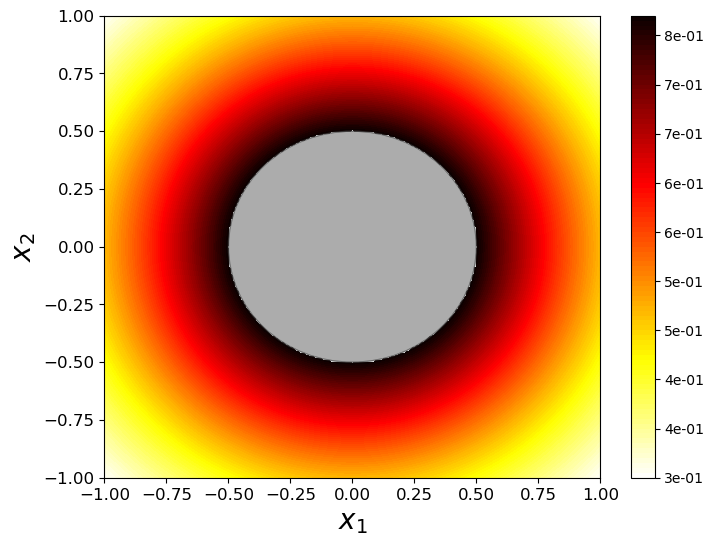

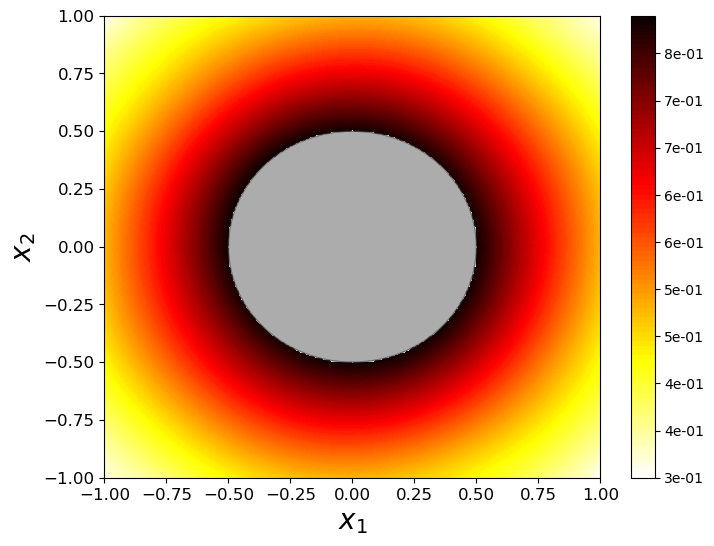

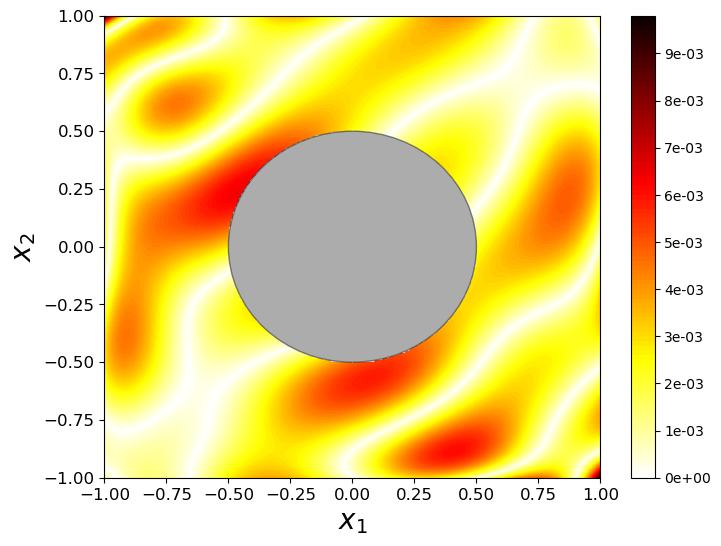

In [32]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

font_format = {"size": 20}

# 假设圆形洞圆心和半径
hole_center = (0.0, 0.0)
hole_radius = 0.5

# mesh
mesh_x, mesh_y = np.linspace(-1.0, 1.0, 257), np.linspace(-1.0, 1.0, 257)
X, Y = np.meshgrid(mesh_x, mesh_y)

# 圆形掩码
shape_matrix = np.ones(X.shape)
dx = X - hole_center[0]
dy = Y - hole_center[1]
mask = dx**2 + dy**2 <= hole_radius**2
shape_matrix[mask] = np.nan  # np.nan 用于绘图透明

# 计算函数值
rho_approx = vmap(aver_fn, [0, 0])(
    X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(X.shape)
rho_ex = vmap(rho, [0, 0])(X, Y)
F, F_hat = rho_ex * shape_matrix, rho_approx * shape_matrix

# 绘图函数，添加圆形洞


def add_hole_shading(ax):
    hole_patch = Circle(
        hole_center,
        hole_radius,
        facecolor="#808080",  # 标准灰
        edgecolor="#404040",
        linewidth=1.0,
        linestyle="-",
        alpha=0.65,  # 增加不透明度让灰色显得更深
        zorder=10,
    )
    ax.add_patch(hole_patch)


# 参考解
plt.figure(figsize=(8, 6))
ax = plt.gca()
plt.contourf(X, Y, F, 100, cmap="hot_r")
add_hole_shading(ax)
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")

# 近似解
plt.figure(figsize=(8, 6))
ax = plt.gca()
plt.contourf(X, Y, F_hat, 100, cmap="hot_r")
add_hole_shading(ax)
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")

# 误差图
error_plot = np.abs(F - F_hat)
error_plot[mask] = np.nan  # 洞内部设置为nan
plt.figure(figsize=(8, 6))
ax = plt.gca()
plt.contourf(X, Y, error_plot, 100, cmap="hot_r")
add_hole_shading(ax)
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")

plt.show()
plt.close()

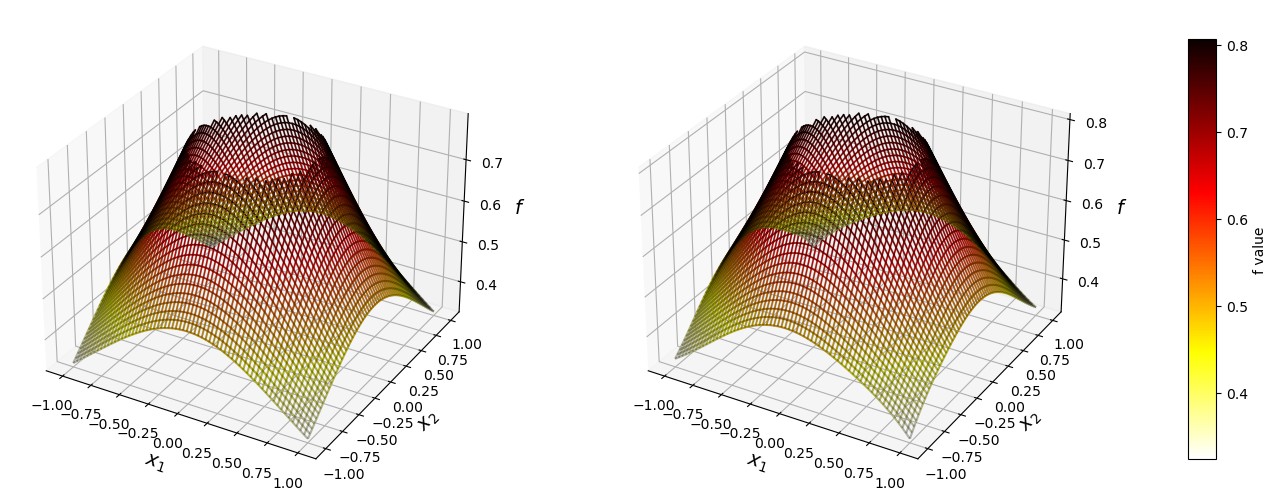

In [31]:
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np
from jax import vmap
import jax.numpy as jnp
from mpl_toolkits.mplot3d import Axes3D

# 设置参数
hole_center = (0.0, 0.0)
hole_radius = 0.5
mesh_x = mesh_y = np.linspace(-1.0, 1.0, 257)
X, Y = np.meshgrid(mesh_x, mesh_y)

# 圆形掩码
mask = (X - hole_center[0]) ** 2 + (Y - hole_center[1]) ** 2 <= hole_radius**2

# 计算函数值（假设aver_fn和rho已定义）
rho_approx = vmap(aver_fn, [0, 0])(

    X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(X.shape)
rho_ex = vmap(rho, [0, 0])(X, Y)

# 应用掩码
F = rho_ex * np.where(mask, np.nan, 1.0)
F_hat = rho_approx * np.where(mask, np.nan, 1.0)

# 创建3D线框图 - 调整整体布局
fig = plt.figure(figsize=(14, 6))  # 宽度从18减小到14

# 统一的颜色映射范围
vmin = min(np.nanmin(F), np.nanmin(F_hat))
vmax = max(np.nanmax(F), np.nanmax(F_hat))
norm = plt.Normalize(vmin, vmax)

# 调整子图位置参数 [left, bottom, width, height]
# 左图 - 更靠左
ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.8], projection="3d")
stride = 4  # 增大步长使线框更清晰

# 绘制线框图（使用颜色映射）
surf1 = ax1.plot_wireframe(
    X[::stride, ::stride],
    Y[::stride, ::stride],
    F[::stride, ::stride],
    rstride=1,
    cstride=1,
    color="black",
    alpha=0.3,
)  # 黑色半透明线框

# 在线上着色
for i in range(0, F.shape[0], stride):
    for j in range(0, F.shape[1], stride):
        if not np.isnan(F[i, j]):
            color = cm.hot_r(norm(F[i, j]))
            ax1.plot(
                [X[i, j], X[min(i + stride, F.shape[0] - 1), j]],
                [Y[i, j], Y[min(i + stride, F.shape[0] - 1), j]],
                [F[i, j], F[min(i + stride, F.shape[0] - 1), j]],
                color=color,
                linewidth=1,
            )
            ax1.plot(
                [X[i, j], X[i, min(j + stride, F.shape[1] - 1)]],
                [Y[i, j], Y[i, min(j + stride, F.shape[1] - 1)]],
                [F[i, j], F[i, min(j + stride, F.shape[1] - 1)]],
                color=color,
                linewidth=1,
            )

ax1.set_xlabel(r"$x_1$", fontsize=14)
ax1.set_ylabel(r"$x_2$", fontsize=14)
ax1.set_zlabel(r"$f$", fontsize=14)

# 右图 - 紧挨着左图
ax2 = fig.add_axes([0.48, 0.1, 0.4, 0.8], projection="3d")  # left从0.5改为0.48

# 绘制线框图
surf2 = ax2.plot_wireframe(
    X[::stride, ::stride],
    Y[::stride, ::stride],
    F_hat[::stride, ::stride],
    rstride=1,
    cstride=1,
    color="black",
    alpha=0.3,
)

# 在线上着色
for i in range(0, F_hat.shape[0], stride):
    for j in range(0, F_hat.shape[1], stride):
        if not np.isnan(F_hat[i, j]):
            color = cm.hot_r(norm(F_hat[i, j]))
            ax2.plot(
                [X[i, j], X[min(i + stride, F_hat.shape[0] - 1), j]],
                [Y[i, j], Y[min(i + stride, F_hat.shape[0] - 1), j]],
                [F_hat[i, j], F_hat[min(i + stride, F_hat.shape[0] - 1), j]],
                color=color,
                linewidth=1,
            )
            ax2.plot(
                [X[i, j], X[i, min(j + stride, F_hat.shape[1] - 1)]],
                [Y[i, j], Y[i, min(j + stride, F_hat.shape[1] - 1)]],
                [F_hat[i, j], F_hat[i, min(j + stride, F_hat.shape[1] - 1)]],
                color=color,
                linewidth=1,
            )

ax2.set_xlabel(r"$x_1$", fontsize=14)
ax2.set_ylabel(r"$x_2$", fontsize=14)
ax2.set_zlabel(r"$f$", fontsize=14)

# 添加colorbar - 更靠右边缘
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # left从0.95改为0.92，更靠边
sm = plt.cm.ScalarMappable(cmap=cm.hot_r, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label="f value")
# plt.show()

In [ ]:
# # ========== 2D Error Profiles: x1 / x2 / boundary-theta ==========
# mesh_x_np = np.asarray(mesh_x)
# mesh_y_np = np.asarray(mesh_y)
# error = np.abs(np.asarray(F_hat) - np.asarray(F)).astype(float)
# eps = 1e-16

# colors = {
#     "primary": "#2E5090",  # Deep blue
#     "secondary": "#C4405E",  # Deep rose
#     "tertiary": "#5D8AA8",  # Steel blue
#     "quaternary": "#A8717A",  # Dusty rose
#     "grid": "#CCCCCC",
#     "light_blue": "#7BA3C4",
#     "light_red": "#D17A8D",
# }
# # ---------- Figure 1: Error along x1 ----------
# fig = plt.figure(figsize=(6.2, 4.8))
# ax1 = fig.add_subplot(111)
# error_max_x = np.nanmax(error, axis=0)
# error_mean_x = np.nanmean(error, axis=0)
# error_min_x = np.nanmin(error, axis=0)
# ax1.semilogy(
#     mesh_x_np,
#     np.maximum(error_max_x, eps),
#     "-",
#     color=colors["primary"],
#     linewidth=2,
#     label="Maximum",
#     zorder=3,
# )
# ax1.semilogy(
#     mesh_x_np,
#     np.maximum(error_mean_x, eps),
#     "--",
#     color=colors["secondary"],
#     linewidth=2,
#     label="Mean",
#     zorder=2,
# )
# ax1.fill_between(
#     mesh_x_np,
#     np.maximum(error_min_x, eps),
#     np.maximum(error_max_x, eps),
#     alpha=0.15,
#     color=colors["primary"],
#     zorder=1,
# )
# ax1.set_xlabel(r"$x_1$", fontsize=13)
# ax1.set_ylabel("Absolute Error", fontsize=13)
# # ax1.set_title("Error along $x_1$", fontsize=13, pad=8)
# ax1.legend(
#     loc="best",
#     frameon=True,
#     framealpha=0.95,
#     edgecolor="black",
#     fancybox=False,
#     shadow=False,
# )
# ax1.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
# ax1.tick_params(direction="in", which="both", top=True, right=True)
# ax1.set_xlim([mesh_x_np[0], mesh_x_np[-1]])
# plt.tight_layout()
# plt.show()

# # ---------- Figure 2: Error along x2 ----------
# fig = plt.figure(figsize=(6.2, 4.8))
# ax2 = fig.add_subplot(111)
# error_max_y = np.nanmax(error, axis=1)
# error_mean_y = np.nanmean(error, axis=1)
# error_min_y = np.nanmin(error, axis=1)
# ax2.semilogy(
#     mesh_y_np,
#     np.maximum(error_max_y, eps),
#     "-",
#     color=colors["primary"],
#     linewidth=2,
#     label="Maximum",
#     zorder=3,
# )
# ax2.semilogy(
#     mesh_y_np,
#     np.maximum(error_mean_y, eps),
#     "--",
#     color=colors["secondary"],
#     linewidth=2,
#     label="Mean",
#     zorder=2,
# )
# ax2.fill_between(
#     mesh_y_np,
#     np.maximum(error_min_y, eps),
#     np.maximum(error_max_y, eps),
#     alpha=0.15,
#     color=colors["primary"],
#     zorder=1,
# )
# ax2.set_xlabel(r"$x_2$", fontsize=13)
# ax2.set_ylabel("Absolute Error", fontsize=13)
# # ax2.set_title("Error along $x_2$", fontsize=13, pad=8)
# ax2.legend(
#     loc="best",
#     frameon=True,
#     framealpha=0.95,
#     edgecolor="black",
#     fancybox=False,
#     shadow=False,
# )
# ax2.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
# ax2.tick_params(direction="in", which="both", top=True, right=True)
# ax2.set_xlim([mesh_y_np[0], mesh_y_np[-1]])
# plt.tight_layout()
# plt.show()